In [16]:
import numpy as np
import pandas as pd

from popt.config import sect, intn, bond, metl, comd, universe
from popt.config import _2W, _1M, _3M, _6M, _1Y, _2Y, _3Y
from popt.alpha.modules.features import (
    momentum,
    momentum_vs,
    drawdown, 
    volatility, 
    volatility_downside, 
    sharpe_like, 
    skewness,
    kurtosis,
)

from popt.alpha.modules.features import FeatureBuilder, FeatureView
from popt.alpha.modules.predictor import RidgeRanker
from popt.alpha.modules.simulator import AlphaSimulator
from popt.alpha.modules.utils import rank_cs

from popt.backtest.modules.backtestdata import DataBuilder, DataLoader
from popt.backtest.modules.strategies import MetaStrategy, FixedWeights, Markowitz, asset_plot
from popt.backtest.modules.simulator import BacktestSimulator, wealth_plot
from popt.backtest.modules.riskmodel import RiskModel

In [17]:
fctr = ["SPY"]
ETF_CATEGORY = bond

TARGET = "mom_1m"
REGRESS = False   # NOTE NOTE NOTE NOTE NOTE NOTE NOTE NOTE NOTE NOTE NOTE NOTE
Z_SCALE = False

LOOKBACK = _1Y
HALFLIFE = np.inf
GAMMA = 100

FIRST_DATE = "2005-01-03"
FINAL_DATE = "2024-12-31"
SPREAD = 5e-4
LEVERAGE = 0.0
VC_LIMIT = 0.08
REBAL_FREQ = "M"

D0 = "1993-01-29"
D1 = "2026-03-24"
riskmodel = RiskModel.load_from_npz("../../data/riskmodel/k10_lb6m_hc6m_hv2m.npz")
rd = pd.read_parquet("../../data/return/return_d.parquet")#.loc[D0:D1]
rf = pd.read_parquet("../../data/return/ffr_d.parquet").reindex(rd.index)
rx = rd - rf.values

bsim = BacktestSimulator(SPREAD)

In [18]:
fb = FeatureBuilder(ret_d=rx, tickers=ETF_CATEGORY, factors=fctr, lookback=_1Y, first_date=D0, final_date=D1)
# add separate methods for adding constant and non-return features (macro and similar?)
# add feature of last days return
# add feature of last weeks returns

fb.add_feature(name="mom_2w", regress=REGRESS, z_scale=Z_SCALE, lookback=_2W, callback=momentum)
fb.add_feature(name="mom_1m", regress=REGRESS, z_scale=Z_SCALE, lookback=_1M, callback=momentum)
fb.add_feature(name="mom_3m", regress=REGRESS, z_scale=Z_SCALE, lookback=_3M, callback=momentum)
fb.add_feature(name="mom_6m", regress=REGRESS, z_scale=Z_SCALE, lookback=_6M, callback=momentum)
fb.add_feature(name="mom_1y", regress=REGRESS, z_scale=Z_SCALE, lookback=_1Y, callback=momentum)
fb.add_feature(name="mom_2y", regress=REGRESS, z_scale=Z_SCALE, lookback=_2Y, callback=momentum)
fb.add_feature(name="mom_3y", regress=REGRESS, z_scale=Z_SCALE, lookback=_3Y, callback=momentum)

fb.add_feature(name="mom_vs_2w", regress=REGRESS, z_scale=Z_SCALE, lookback=_2W, callback=momentum_vs)
fb.add_feature(name="mom_vs_1m", regress=REGRESS, z_scale=Z_SCALE, lookback=_1M, callback=momentum_vs)
fb.add_feature(name="mom_vs_3m", regress=REGRESS, z_scale=Z_SCALE, lookback=_3M, callback=momentum_vs)
fb.add_feature(name="mom_vs_6m", regress=REGRESS, z_scale=Z_SCALE, lookback=_6M, callback=momentum_vs)
fb.add_feature(name="mom_vs_1y", regress=REGRESS, z_scale=Z_SCALE, lookback=_1Y, callback=momentum_vs)
fb.add_feature(name="mom_vs_2y", regress=REGRESS, z_scale=Z_SCALE, lookback=_2Y, callback=momentum_vs)
fb.add_feature(name="mom_vs_3y", regress=REGRESS, z_scale=Z_SCALE, lookback=_3Y, callback=momentum_vs)

fb.add_feature(name="mdd_2w", regress=REGRESS, z_scale=Z_SCALE, lookback=_2W, callback=drawdown)
fb.add_feature(name="mdd_1m", regress=REGRESS, z_scale=Z_SCALE, lookback=_1M, callback=drawdown)
fb.add_feature(name="mdd_3m", regress=REGRESS, z_scale=Z_SCALE, lookback=_3M, callback=drawdown)
fb.add_feature(name="mdd_6m", regress=REGRESS, z_scale=Z_SCALE, lookback=_6M, callback=drawdown)
fb.add_feature(name="mdd_1y", regress=REGRESS, z_scale=Z_SCALE, lookback=_1Y, callback=drawdown)
fb.add_feature(name="mdd_2y", regress=REGRESS, z_scale=Z_SCALE, lookback=_2Y, callback=drawdown)
fb.add_feature(name="mdd_3y", regress=REGRESS, z_scale=Z_SCALE, lookback=_3Y, callback=drawdown)

fb.add_feature(name="vol_2w", regress=REGRESS, z_scale=Z_SCALE, lookback=_2W, callback=volatility)
fb.add_feature(name="vol_1m", regress=REGRESS, z_scale=Z_SCALE, lookback=_1M, callback=volatility)
fb.add_feature(name="vol_3m", regress=REGRESS, z_scale=Z_SCALE, lookback=_3M, callback=volatility)
fb.add_feature(name="vol_6m", regress=REGRESS, z_scale=Z_SCALE, lookback=_6M, callback=volatility)
fb.add_feature(name="vol_1y", regress=REGRESS, z_scale=Z_SCALE, lookback=_1Y, callback=volatility)
fb.add_feature(name="vol_2y", regress=REGRESS, z_scale=Z_SCALE, lookback=_2Y, callback=volatility)
fb.add_feature(name="vol_3y", regress=REGRESS, z_scale=Z_SCALE, lookback=_3Y, callback=volatility)

fb.add_feature(name="skw_2w", regress=REGRESS, z_scale=Z_SCALE, lookback=_2W, callback=skewness)
fb.add_feature(name="skw_1m", regress=REGRESS, z_scale=Z_SCALE, lookback=_1M, callback=skewness)
fb.add_feature(name="skw_3m", regress=REGRESS, z_scale=Z_SCALE, lookback=_3M, callback=skewness)
fb.add_feature(name="skw_6m", regress=REGRESS, z_scale=Z_SCALE, lookback=_6M, callback=skewness)
fb.add_feature(name="skw_1y", regress=REGRESS, z_scale=Z_SCALE, lookback=_1Y, callback=skewness)
fb.add_feature(name="skw_2y", regress=REGRESS, z_scale=Z_SCALE, lookback=_2Y, callback=skewness)
fb.add_feature(name="skw_3y", regress=REGRESS, z_scale=Z_SCALE, lookback=_3Y, callback=skewness)

fb.add_feature(name="krt_2w", regress=REGRESS, z_scale=Z_SCALE, lookback=_2W, callback=kurtosis)
fb.add_feature(name="krt_1m", regress=REGRESS, z_scale=Z_SCALE, lookback=_1M, callback=kurtosis)
fb.add_feature(name="krt_3m", regress=REGRESS, z_scale=Z_SCALE, lookback=_3M, callback=kurtosis)
fb.add_feature(name="krt_6m", regress=REGRESS, z_scale=Z_SCALE, lookback=_6M, callback=kurtosis)
fb.add_feature(name="krt_1y", regress=REGRESS, z_scale=Z_SCALE, lookback=_1Y, callback=kurtosis)
fb.add_feature(name="krt_2y", regress=REGRESS, z_scale=Z_SCALE, lookback=_2Y, callback=kurtosis)
fb.add_feature(name="krt_3y", regress=REGRESS, z_scale=Z_SCALE, lookback=_3Y, callback=kurtosis)

fb.consolidate()

Backtest Runtime: 499 ms
ic sprm:    0.018
ic prsn:    0.0091
Backtest Runtime: 1410 ms
Ann Sharpe: 0.2958
Tot Ret:    0.8135
Ann Ret:    0.0303
Ann Vol:    0.0452
Max DD :    0.1001


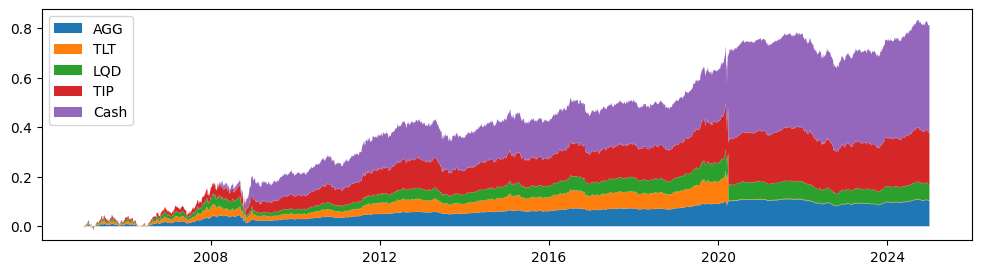

In [42]:
fv = FeatureView(fb, target=TARGET, subset=["skw_1m", "mom_1m"])

rr = RidgeRanker(lookback=LOOKBACK, halflife=HALFLIFE, gamma=GAMMA)
asim = AlphaSimulator(fv)
asim.run(predictor=rr, verbose=True, permute=False)
alpha = asim.get_alpha(universe, cheat=False, rank=False)

# alpha[:] = 1.0
# alpha[:] = np.random.random(alpha.shape)

db = DataBuilder(
    universe=rd.columns,
    first_date=FIRST_DATE,
    final_date=FINAL_DATE,
    alpha=alpha,
    rd=rd,
    rf=rf,
    riskmodel=riskmodel,
    rebal_freq=REBAL_FREQ,
)
dl = DataLoader(db=db, tickers=ETF_CATEGORY)
m = Markowitz(
    dl=dl,
    lookahead=0,
    gamma=SPREAD,
    lev=LEVERAGE,
    w_max=0.7*np.ones(dl.N),
    vc_lim=VC_LIMIT,
)
bsim.run(strategy=m, verbose=True)

sharpe = np.round(bsim.ann_sharpe, decimals=4)
spearm = np.round(np.nanmean(asim.ic_spearman), decimals=4)
pearsn = np.round(np.nanmean(asim.ic_pearson), decimals=4)
# thetas = asim.thetas[:,i]
# u_theta = np.nanmean(thetas).round(4)
# s_theta = np.nanstd(thetas).round(4)

wealth_plot(bsim)

In [34]:
alpha[bond].iloc[5000:5500]

,AGG,TLT,LQD,TIP
Date,,,,
2012-12-05,-2.174646e-08,3.088265e-08,-3.244569e-08,1.085065e-08
2012-12-06,-9.288864e-09,3.737584e-08,-1.889149e-08,6.536671e-09
2012-12-07,-1.415710e-08,1.483220e-08,-1.389437e-08,4.693890e-09
2012-12-10,-1.274963e-08,-2.981910e-08,-1.888189e-08,-9.081458e-09
2012-12-11,-1.259100e-08,-2.121413e-08,-2.365014e-08,-5.079982e-09
...,...,...,...,...
2014-11-21,-8.082115e-09,-1.254479e-09,-2.886762e-08,-4.433901e-08
2014-11-24,-7.919119e-09,-1.656870e-09,-2.365149e-08,-3.641162e-08
2014-11-25,-4.334983e-09,-1.869569e-09,-2.088289e-08,-2.847188e-08


In [32]:
ref = pd.DataFrame(asim.ref, columns=asim.fv.tickers, index=asim.fv.timeline).dropna()
ref.describe().T

,count,mean,std,min,25%,50%,75%,max
AGG,5295.0,0.001153,0.013298,-0.127863,-0.005427,0.001990,0.008555,0.102522
TLT,5295.0,0.001824,0.039362,-0.149004,-0.022716,0.000881,0.024387,0.265336
LQD,5295.0,0.002064,0.023404,-0.197037,-0.008707,0.003076,0.013822,0.238827
TIP,5295.0,0.001407,0.016250,-0.099283,-0.007559,0.002230,0.010475,0.109936


In [21]:
# from itertools import combinations
# fv = FeatureView(fb, target="mom_1m", subset=None)
# feature_combinations = combinations(fv.features, r=2)

# for i, (f1, f2) in enumerate(feature_combinations):
#     fv = FeatureView(fb, target="mom_1m", subset=[f1, f2])

#     rr = RidgeRanker(lookback=LOOKBACK, halflife=HALFLIFE, gamma=GAMMA)
#     asim = AlphaSimulator(fv)
#     asim.run(predictor=rr, verbose=False, permute=False)
#     alpha = asim.get_alpha(universe)

#     # alpha[:] = 1.0
#     # alpha[:] = np.random.random(alpha.shape)

#     db = DataBuilder(
#         universe=rd.columns,
#         first_date=FIRST_DATE,
#         final_date=FINAL_DATE,
#         alpha=alpha,
#         rd=rd,
#         rf=rf,
#         riskmodel=riskmodel,
#         rebal_freq=REBAL_FREQ,
#     )
#     dl = DataLoader(db=db, tickers=ETF_CATEGORY)
#     m = Markowitz(
#         dl=dl,
#         lookahead=0,
#         gamma=SPREAD,
#         lev=LEVERAGE,
#         w_max=0.7*np.ones(dl.N),
#         vc_lim=VC_LIMIT,
#     )
#     bsim.run(strategy=m, verbose=False)

#     sharpe = np.round(bsim.ann_sharpe, decimals=4)
#     spearm = np.round(np.nanmean(asim.ic_spearman), decimals=4)
#     pearsn = np.round(np.nanmean(asim.ic_pearson), decimals=4)
#     # thetas = asim.thetas[:,i]
#     # u_theta = np.nanmean(thetas).round(4)
#     # s_theta = np.nanstd(thetas).round(4)

#     print(f1, f2, sharpe, spearm, pearsn)
#     # wealth_plot(bsim)

# # NOTE without rank post processing
# # sect -> 0.5824 0.0168 krt_3y (0.5012) raw
# # bond -> 0.3687 -0.0375 skw_3y (0.2774) raw
# # metl -> 0.4892 0.0792 mom_vs_3m (0.3951) raw
# # intn -> 0.4095 0.0297 mom_2w (0.0854) raw
# # comd -> -0.0155 -0.0043 mdd_2w (-0.2014) raw

In [22]:
# sharpes = pd.read_csv("../../.deprecated/bond_2f.csv")
# sharpes.sort_values("sharpe", ascending=False).head(25)

In [23]:
# alpha = 1    : ...
# random alpha : ...
# alpha perm y : ...

In [24]:
# sharpes = pd.read_csv("../../.deprecated/sect_2f.csv")
# sharpes.sort_values("sharpe", ascending=False).head(25)

# sharpes = pd.read_csv("../../.deprecated/sect_mdd1y_3f.csv")
# sharpes.sort_values("sharpe", ascending=False).head(25)

In [25]:
# N = 500
# sharpes_rand_perm = []
# for i in range(N):
#     fv = FeatureView(fb, target="mom_1m", subset=["mdd_1y", "skw_3m"])

#     rr = RidgeRanker(lookback=LOOKBACK, halflife=HALFLIFE, gamma=GAMMA)
#     asim = AlphaSimulator(fv)
#     asim.run(predictor=rr, verbose=False, permute=True)
#     alpha = asim.get_alpha(universe)

#     # alpha[:] = 1.0
#     # alpha[:] = np.random.random(alpha.shape)

#     db = DataBuilder(
#         universe=rd.columns,
#         first_date=FIRST_DATE,
#         final_date=FINAL_DATE,
#         alpha=alpha,
#         rd=rd,
#         rf=rf,
#         riskmodel=riskmodel,
#         rebal_freq=REBAL_FREQ,
#     )
#     dl = DataLoader(db=db, tickers=ETF_CATEGORY)
#     m = Markowitz(
#         dl=dl,
#         lookahead=0,
#         gamma=SPREAD,
#         lev=LEVERAGE,
#         w_max=0.7*np.ones(dl.N),
#         vc_lim=VC_LIMIT,
#     )
#     bsim.run(strategy=m, verbose=False)

#     sharpe = np.round(bsim.ann_sharpe, decimals=4)
#     spearm = np.round(np.nanmean(asim.ic_spearman), decimals=4)
#     pearsn = np.round(np.nanmean(asim.ic_pearson), decimals=4)

#     print(i, sharpe)
#     sharpes_rand_perm.append(sharpe)
#     # wealth_plot(bsim)

# # krt_2w
# # p_val = (1 + np.sum(np.array(sharpes_rand_perm) >= 0.6550)) / (N+1)
# # p_val -> 0.031936127744510975

# # mdd_1y, skw_3m
# # p_val = (1 + np.sum(np.array(sharpes_rand_perm) >= 0.7536)) / (N+1)
# # p_val -> 0.003992015968063872

In [26]:
# # periods = [
# #     ("2005-01-03", "2014-12-31", "2015-01-03", "2015-12-31"),
# #     ("2006-01-03", "2015-12-31", "2016-01-04", "2016-12-30"),
# #     ("2007-01-03", "2016-12-30", "2017-01-03", "2017-12-29"),
# #     ("2008-01-02", "2017-12-29", "2018-01-02", "2018-12-31"),
# #     ("2009-01-02", "2018-12-31", "2019-01-02", "2019-12-31"),
# #     ("2010-01-04", "2019-12-31", "2020-01-02", "2020-12-31"),
# #     ("2011-01-03", "2020-12-31", "2021-01-04", "2021-12-31"),
# #     ("2012-01-03", "2021-12-31", "2022-01-03", "2022-12-30"),
# #     ("2013-01-02", "2022-12-30", "2023-01-03", "2023-12-29"),
# #     ("2014-01-02", "2023-12-29", "2024-01-02", "2024-12-31"),
# # ]

# # fb = FeatureBuilder(ret_d=rx, tickers=ETF_CATEGORY, factors=fctr, lookback=_1Y, first_date=d0_trn, final_date=d1_trn)
#     # fb.add_feature(name="mom_1m", regress=REGRESS, z_scale=Z_SCALE, lookback=_1M, callback=momentum)
#     # fb.add_feature(name="mdd_1y", regress=REGRESS, z_scale=Z_SCALE, lookback=_1Y, callback=drawdown)
#     # fb.add_feature(name="skw_3m", regress=REGRESS, z_scale=Z_SCALE, lookback=_3M, callback=skewness)
#     # fb.add_feature(name="krt_2w", regress=REGRESS, z_scale=Z_SCALE, lookback=_2W, callback=kurtosis)
#     # fb.consolidate()
# FIRST_DATE = "2005-01-03"
# FINAL_DATE = "2024-12-31"

# periods = (
#     ("2005-01-03", "2005-12-30"),
#     ("2006-01-03", "2006-12-29"),
#     ("2007-01-03", "2007-12-31"),
#     ("2008-01-02", "2008-12-31"),
#     ("2009-01-02", "2009-12-31"),
#     ("2010-01-04", "2010-12-31"),
#     ("2011-01-03", "2011-12-30"),
#     ("2012-01-03", "2012-12-31"),
#     ("2013-01-02", "2013-12-31"),
#     ("2014-01-02", "2014-12-31"),
#     ("2015-01-02", "2015-12-31"),
#     ("2016-01-04", "2016-12-30"),
#     ("2017-01-03", "2017-12-29"),
#     ("2018-01-02", "2018-12-31"),
#     ("2019-01-02", "2019-12-31"),
#     ("2020-01-02", "2020-12-31"),
#     ("2021-01-04", "2021-12-31"),
#     ("2022-01-03", "2022-12-30"),
#     ("2023-01-03", "2023-12-29"),
#     ("2024-01-02", "2024-12-31"),
# )
# results = []
# for i, (d0_trn, d1_trn) in enumerate(periods):  # , d0_tst, d1_tst
#     for f in fb.features:
#         fv = FeatureView(fb, target="mom_1m", subset=[f])

#         rr = RidgeRanker(lookback=LOOKBACK, halflife=HALFLIFE, gamma=GAMMA)
#         asim = AlphaSimulator(fv)
#         asim.run(predictor=rr, verbose=False, permute=False)
#         alpha = asim.get_alpha(universe)

#         db = DataBuilder(
#             universe=rd.columns,
#             first_date=d0_trn,
#             final_date=d1_trn,
#             alpha=alpha,
#             rd=rd,
#             rf=rf,
#             riskmodel=riskmodel,
#             rebal_freq=REBAL_FREQ,
#         )
#         dl = DataLoader(db=db, tickers=ETF_CATEGORY)
#         m = Markowitz(
#             dl=dl,
#             lookahead=0,
#             gamma=SPREAD,
#             lev=LEVERAGE,
#             w_max=0.7*np.ones(dl.N),
#             vc_lim=VC_LIMIT,
#         )
#         bsim.run(strategy=m, verbose=False)
#         # wealth_plot(bsim)

#         sharpe = np.round(bsim.ann_sharpe, decimals=4)
#         # spearm = np.round(np.nanmean(asim.ic_spearman), decimals=4)
#         # pearsn = np.round(np.nanmean(asim.ic_pearson), decimals=4)
#         # spearm, pearsn
#         # print(f, d0_trn, d1_trn, sharpe)
#         print([d0_trn[:4], sharpe.item(), f])
#         results.append([d0_trn[:4], sharpe.item(), f])
# results
# # We are NOT asking: Does this rank assets correctly? (IC ≈ 0, negative sometimes)
# # Sharpe survives / even improved on flipped alpha
# # We are asking: Does this signal improve timing of exposure to the ETF?

# pd.DataFrame(results, columns=["year", "sharpe", "feature"]).to_csv("../../.deprecated/top5.csv", index=False)

In [27]:
# import matplotlib.pyplot as plt

# top5 = pd.read_csv("../../.deprecated/top5.csv")
# top5.loc[top5["feature"] == "mom_vs_2y", ["sharpe"]].describe().T
# for f in top5["feature"].unique():
#     top5.loc[top5["feature"] == f, "sharpe"].plot(figsize=(12,3), title=f)
#     plt.show()